In [1]:
from mpmath import mp, mpf, log
import numpy as np
import matplotlib.pyplot as plt

In [2]:
mp.dps = 300  # adjust if needed

In [3]:
def rate_ratio(M, k):
    # NrateRatio[M_, k_] := N[Exp[-3*k/M]];
    return mp.e ** (-3 * mp.mpf(k) / mp.mpf(M))

In [4]:
def pi_N(n, M, k):
    # NpiN[n_, M_, k_] := If[k != 0, (1 - r)/(1 - r^n), 1/n];
    if k != 0:
        r = rate_ratio(M, k)
        return (1 - r) / (1 - r ** n)
    else:
        return mp.mpf(1) / n

In [5]:
def adjacent_dists_KLD(n, M, k):
    # NadjacentDistsKLD[n_, M_, k_] := -Log[pi_N(n,M,k+1)/pi_N(n,M,k)]
    #   + If[k != 0,
    #        3/M * (r - n*r^n + (n-1)*r^(n+1)) / ((1 - r)*(1 - r^n)),
    #        3*(n - 1)/(2*M)
    #     ];
    term1 = -mp.log(pi_N(n, M, k + 1) / pi_N(n, M, k))
    if k != 0:
        r = rate_ratio(M, k)
        num = r - n * (r ** n) + (n - 1) * (r ** (n + 1))
        den = (1 - r) * (1 - r ** n)
        term2 = (3 / mp.mpf(M)) * (num / den)
    else:
        term2 = 3 * (n - 1) / (2 * mp.mpf(M))
    return term1 + term2


In [6]:
def total_ent_prod(n, M):
    # NtotalEntProd[n_, M_] := Sum[adjacent_dists_KLD[n,M,k], {k, -M, M}];
    s = mp.mpf('0')
    for k in range(-int(M), int(M) + 1):
        s += adjacent_dists_KLD(n, M, k)
    return s

In [7]:
def entropy_sum(n, M):
    # EntropySum[n_, M_] := NSum[If[k != 0, ..., 3*(n - 1)/(2*M)], {k, -M, M}]
    s = mp.mpf('0')
    for k in range(-int(M), int(M) + 1):
        if k != 0:
            r = rate_ratio(M, k)
            num = r - n * (r ** n) + (n - 1) * (r ** (n + 1))
            den = (1 - r) * (1 - r ** n)
            term = (3 / mp.mpf(M)) * (num / den)
        else:
            term = 3 * (n - 1) / (2 * mp.mpf(M))
        s += term
    return s

In [8]:
def log_sum(n, M): 
    s = mp.mpf('0') 
    for k in range(-int(M), int(M)+1): 
        s += -mp.log(pi_N(n, M, k + 1) / pi_N(n, M, k))
        
    return s
            

In [9]:
def constant_protocol_formula(n, M): 
    c_delta = 3

    sigma_tot = c_delta/M * ( n/(1-mp.exp(-c_delta*n)) - mp.exp(c_delta)/((-1+mp.exp(c_delta))*(1-mp.exp(-c_delta*n))) - 1/2 * (n-1) ) 
    return sigma_tot

In [10]:
sum_arr = np.asarray([total_ent_prod(10, m) for m in range(5,300, 5)])
formula_arr = np.asarray([constant_protocol_formula(10, m) for m in range(5,300, 5)])

In [11]:
print((sum_arr - formula_arr)/sum_arr)

[mpf('0.0030157997917562565844066425816043432048395618023364486394041227829837060869538660708179740670514514964366992130017470448948629696670876016221938978866568092924886399988651873432245814494560564639451695615054995676799055407911022242771606693430093492162326976563517538290680413127925835187376557043979147')
 mpf('0.0016685836723019393658784905824113283172246308695890625436859230281931177590453747431054531179536062513851777173455204498892871162551232855390869267004525977446845102030838724776908739842334690944248717065569724435609228510799677634207403427302812608587780696088314965113509684028212066817421957992493299')
 mpf('0.00115235984511139444792614299216389052510561756797639151007678567424225201868130107470201755372040000968438694701923509550806599695900336945129931766460699783467929359353579563733197451545208542102218076434208521202574987430695139593083521757071435448246365374388456997680969043388804678647988266953794054')
 mpf('0.0008799323068557632720927265833847126670548973

In the following section I am implementing some functions which will calculate the total entropy production of the constant force protocol by directly calculating and summing up the KLD between subsequent equilibrium distributions. I then check these against functions that use my derivations to make sure that my derivations for the entropy production are correct.

In [12]:
#This block was written by Claude, be careful
def kl_divergence(p, q, precision=50):
    """
    Calculate the Kullback-Leibler divergence between two discrete probability distributions.
    
    KL(P || Q) = sum_i P(i) * log(P(i) / Q(i))
    
    Parameters:
    -----------
    p : array-like
        The first probability distribution (must sum to 1)
    q : array-like
        The second probability distribution (must sum to 1)
    precision : int, optional
        Number of decimal places for arbitrary precision arithmetic (default: 50)
    
    Returns:
    --------
    mpf
        The KL divergence value with arbitrary precision
    
    Notes:
    ------
    - Both distributions must have the same length
    - All probabilities must be non-negative
    - Both distributions must sum to 1 (within numerical precision)
    - KL divergence is undefined when Q(i) = 0 but P(i) > 0
    """
    # Set precision for mpmath
    mp.dps = precision
    
    # Convert inputs to numpy arrays
    p = np.array(p, dtype=float)
    q = np.array(q, dtype=float)
    
    # Validate inputs
    if len(p) != len(q):
        raise ValueError(f"Distributions must have same length. Got p: {len(p)}, q: {len(q)}")
    
    if np.any(p < 0) or np.any(q < 0):
        raise ValueError("All probabilities must be non-negative")
    
    # Check if distributions sum to 1 (with tolerance)
    p_sum = np.sum(p)
    q_sum = np.sum(q)
    tolerance = 1e-10
    
    if abs(p_sum - 1.0) > tolerance:
        raise ValueError(f"Distribution p must sum to 1. Current sum: {p_sum}")
    
    if abs(q_sum - 1.0) > tolerance:
        raise ValueError(f"Distribution q must sum to 1. Current sum: {q_sum}")
    
    # Calculate KL divergence with arbitrary precision
    kl_div = mpf(0)
    
    for i in range(len(p)):
        p_i = mpf(p[i])
        q_i = mpf(q[i])
        
        # Skip terms where p_i is zero (contributes 0 to sum by convention)
        if p_i == 0:
            continue
        
        # Check for undefined case: p_i > 0 but q_i = 0
        if q_i == 0:
            raise ValueError(f"KL divergence is undefined: Q({i}) = 0 but P({i}) = {p[i]} > 0")
        
        # Add contribution: p_i * log(p_i / q_i)
        kl_div += p_i * log(p_i / q_i)
    
    return kl_div

In [13]:
p = [0.7, 0.2, 0.1]
q = [0.1, 0.2, 0.7] 

kl_divergence(p,q) 

mpf('1.167546089433187814473990181607503277517680773286039')

In [14]:
def get_chain_dist(n, r): 

    if r == 1: 
        dist = np.full(n, 1/n)
        
    else: 
        pi_n = (1-r)/(1-r**n) 
        dist = np.full(n, pi_n)
        
        for i in range(n-1, 0, -1): 
            dist[:i] *= r

    return dist

    

In [15]:

delta = mp.exp(-3) 
c_delta = -mp.log(delta)

ratio_sequence = lambda m: np.asarray([1/delta*mp.exp(-2*k*c_delta/m) for k in range(m+1)])


In [16]:
def get_dist_seq(n, m): 
    ratio_seq = ratio_sequence(m)
    dist_seq = [get_chain_dist(n, r) for r in ratio_seq]

    return np.asarray(dist_seq) 

In [17]:
def calc_entropy_prod(n, m): 
    
    total_ent = 0
    dist_seq = get_dist_seq(n, m)
    
    for i in range(m): 

        total_ent += kl_divergence(dist_seq[i], dist_seq[i+1])

    return total_ent

In [18]:
derivation_check_mat = []
for n in range(10, 100, 5):
    x = np.asarray([calc_entropy_prod(n, 2*m) for m in range(10, 100, 5)])
    y = np.asarray([total_ent_prod(n, m) for m in range(10, 100, 5)])
    max_err = np.max((x-y)/x)
    derivation_check_mat.append(max_err)

In [19]:
total_ent_prod(10,10)

mpf('1.3365113721062166446919237149919570555180348320124883')

In [20]:
print(max(derivation_check_mat))

-0.000018331453419858253769791474799175178983628378677344


Now I want to implement the function $\Phi_N(x)$ and see if the approximate solutions I find in Mathematica match the solutions to the exact equation.

In [21]:
def phi(x, n):
    if x == 1:
        return (n - 1) / 2
    else:
        nom = x - n * (x**n) + (n - 1) * (x ** (n + 1))
        denom = (1 - x) * (1 - x**n)

        return nom / denom


In [22]:
from scipy.optimize import fsolve

In [23]:
M = 300

upper_solution_ls = np.zeros(M-4)

for n in range(5, M+1): 
    f = lambda x: phi(x, n) - 3/4*n
    
    sol = fsolve(f, 0.9) 
    upper_solution_ls[n-5] = sol[0]
    


In [24]:


lower_solution_ls = np.zeros(M-4)

for n in range(5, M+1): 
    f = lambda x: phi(x, n) - 1/4*n
    
    sol = fsolve(f, 0.9) 
    lower_solution_ls[n-5] = sol[0]

Importing the solutions to the approximate equations I found and then numerically solved on Mathematica. The solutions are in fact in terms of a transformed variable $r$ which is defined by $x = 1 + r/N$, so I transform them accordingly before comparing with the solutions of the exact equation.

In [25]:
approx_sols = np.loadtxt("UpperApproxSols.csv", delimiter=',')
approx_asymptotic_sols = np.loadtxt("UpperApproxAsymptoticSols.csv", delimiter=',')

In [26]:
n_vec = np.asarray([1/n for n in range(5,301)])
scaled_approx_sols = 1 + approx_sols*n_vec

In [27]:
np.savetxt("ExactEquationUpperSolutions.csv", upper_solution_ls, delimiter=',')
np.savetxt("ExactEquationLowerSolutions.csv", lower_solution_ls, delimiter=',')

In [3]:
import pickle as pkl

In [4]:
#These are the optimisation results for m= 6 and m= 7. Both with n = 10

with open('optimisation_data/random_init_m6.pkl', 'rb') as file: 
    rand_init_m6 = pkl.load(file)

with open('optimisation_data/random_init_m7.pkl', 'rb') as file: 
    rand_init_m7 = pkl.load(file)


In [5]:
#The minimum entropy found after each optimisation run
min_ent_ls_m6 = [rand_init_m6[i][1] for i in range(len(rand_init_m6))]
min_ent_ls_m7 = [rand_init_m7[i][1] for i in range(len(rand_init_m7))]

In [6]:
#The min and max are the (almost) equal, hence all elements are equal
print(min(min_ent_ls_m6), max(min_ent_ls_m6))

29.608900994394936 29.60890266969303


In [41]:
#The min and max are the (almost) equal, hence all elements are equal
print(min(min_ent_ls_m7), max(min_ent_ls_m7))

29.248379156199515 29.248382460082308


In [24]:
optimal_numerical_cost = np.load("optimisation_data/optimalProtocolCost_10_5_100_5_constant.npy", allow_pickle=True)

In [25]:
optimal_numerical_cost = optimal_numerical_cost-9*3

In [2]:
geodesic_lengths = np.load("optimisation_data/geodesic_lengths.npy") 


In [3]:
np.savetxt("geodesic_lengths.csv", geodesic_lengths, delimiter=',')

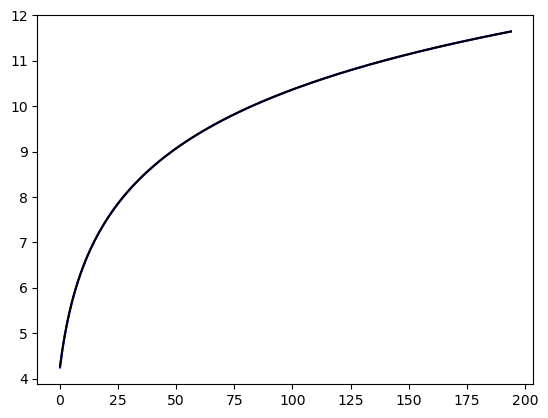

In [63]:
plt.plot(geodesic_lengths, color="blue")
# plt.plot([i**(1/3)+6 for i in range(5,200)], color='red')
# plt.plot([i**(1/2) for i in range(5,200)], color='orange')
plt.plot([2*np.log(i)+1.0581 for i in range(5,200)], color='black')

plt.show()

In [67]:
(2*np.log(10)+1.058)**2/6

5.345249425910733

In [69]:
len(optimal_numerical_cost)

20

In [68]:
[(2*np.log(10)+1.058)**2/(6*i) for i in range(5,100,5)]

[1.0690498851821466,
 0.5345249425910733,
 0.3563499617273822,
 0.26726247129553665,
 0.21380997703642934,
 0.1781749808636911,
 0.1527214121688781,
 0.13363123564776833,
 0.11878332057579408,
 0.10690498851821467,
 0.09718635319837697,
 0.08908749043184555,
 0.08223460655247282,
 0.07636070608443905,
 0.07126999234547644,
 0.06681561782388416,
 0.06288528736365569,
 0.05939166028789704,
 0.056265783430639295]

In [4]:
asymptotic_arr = np.array([2*np.log(i)+1.058 for i in range(5,200)])

In [6]:
err_arr = np.abs(geodesic_lengths - asymptotic_arr)

In [7]:
np.savetxt("geodesic_asymptotics_err.csv", err_arr, delimiter=',')